# Testes não paramétricos

Os testes paramétricos, aplicados para dados de natureza quantitativa, formulam hipóteses sobre os parâmetros da população, como a média populacional $\mu$,o desvio-padrão populacional $\sigma$, a variância populacional $\sigma^2$, a proporção populacional $p$, etc.

Os testes paramétricos exigem suposições fortes em relação à distribuição dos dados. Por exemplo, em muitos casos, devemos supor que as amostras sejam retiradas de populações cujos dados apresentem distribuição gaussiana. Ou ainda, para testes de comparação de duas médias populacionais emparelhadas ou $k$ médias populacionais ($k \ge 3$), as variâncias populacionais devem ser homogêneas.

Os **testes não paramétricos** podem formular hipóteses sobre características qualitativas da população, podendo então ser aplicados para dados de natureza qualitativa, em escala nominal ou ordinal. Como as suposições em relação à distribuição dos dados são em menor número e mais fracas do que as provas paramétricas, são também conhecidos como testes livres de distribuição.

Os testes não paramétricos são uma alternativa aos paramétricos quando as hipóteses destes últimos forem violadas. Por exigirem um número menor de pressupostos, são mais simples e de fácil aplicação, porém, menos robustos quando comparados aos testes paramétricos.

Em resumo, as principais vantagens dos testes não paramétricos são:

- Podem ser aplicados em grande variedade de situações, pois não exigem premissas rígidas sobre a população, como ocorre com os métodos paramétricos. Em particular, os métodos não paramétricos não exigem que as populações apresentem dados com distribuição normal.
- Diferente dos métodos paramétricos, os não paramétricos podem ser aplicados para dados qualitativos, em escala nominal e ordinal.
- São fáceis de aplicar, por envolverem cálculos mais simples quando comparados aos métodos paramétricos.

As principais desvantagens são:

- No caso de dados quantitativos, como eles devem ser transformados em dados qualitativos para aplicação dos testes não paramétricos, perdemos muita informação.
- Como os testes não paramétricos são menos eficientes do que os paramétricos, necessitamos de maior evidência (uma amostra maior ou com diferenças maiores) para rejeitar a hipótese nula.

## Testes para uma amostra

### Teste qui-quadrado para uma amostra

É aplicado a uma única amostra em que a variável em estudo assume duas ou mais categorias. As variáveis podem ser de natureza nominal ou ordinal. O teste compara as frequências observadas com as frequências esperadas em cada categoria.

Exemplo: Uma loja de roupas deseja verificar se o número de itens vendidos diariamente varia em função do dia da semana. Para isso, uma amostra é coletada ao longo de uma semana, escolhida aleatoriamente, e os resultados estão na base a seguir. Teste a hipótese de que as vendas independem do dia da semana. Considere $\alpha = 5\%$.

In [1]:
import pandas as pd

DADOS_VENDAS = "./dados/sales_day.csv"

df_vendas = pd.read_csv(DADOS_VENDAS)

df_vendas

,Day,Sales
0,Sun,35
1,Mon,24
2,Tue,27
3,Wed,32
4,Thu,25
5,Fri,36
6,Sat,31


In [2]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Day     7 non-null      object
 1   Sales   7 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 244.0+ bytes


In [3]:
df_vendas.describe()

,Sales
count,7.000000
mean,30.000000
std,4.760952
min,24.000000
25%,26.000000
50%,31.000000
75%,33.500000
max,36.000000


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chisquare.html

In [5]:
from scipy.stats import chisquare

chisquare(df_vendas['Sales'])

Power_divergenceResult(statistic=np.float64(4.533333333333333), pvalue=np.float64(0.6048969327419378))

In [6]:
chisquare(df_vendas['Sales'],30)

Power_divergenceResult(statistic=np.float64(4.533333333333333), pvalue=np.float64(0.6048969327419378))

Como $pvalue > 0.05$ não rejeitamos $H_0$ o que, ao nível de confiança de 95 %, significa que as vendas independem do dia da semana.

Para calcular o grau de liberdade em uma análise qui-quadrado, usamos a fórmula:

$$ \text{graus de liberdade} = (r - 1) \times (c - 1) $$

onde $ r $ é o número de linhas e $ c $ é o número de colunas.

- $ r = 7 $ 
- $ c = 2 $ (colunas: Day e Sales)

Aplicando a fórmula:

$$ \text{graus de liberdade} = (7 - 1) \times (2 - 1) = 6 \times 1 = 6 $$


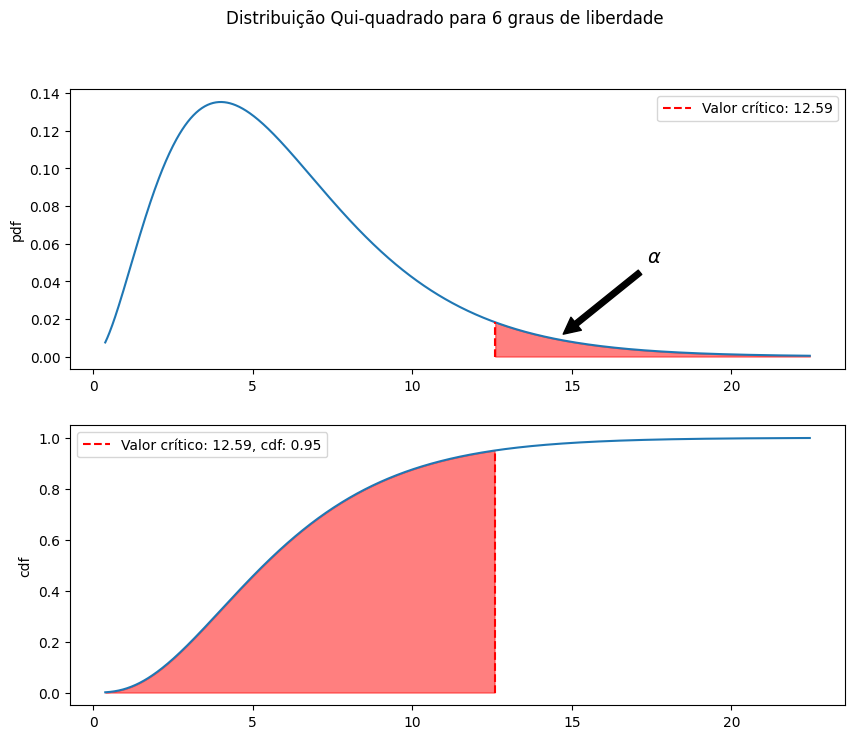

In [7]:
from graficos import plot_chi2

plot_chi2(6, 0.05)